
Logistic Regression
Accuracy: 0.8279680365296803
Precision: 0.8224471021159153
Recall: 0.8295059151009047
F1 Score: 0.8259614274165608
Confusion Matrix:
 [[3677  772]
 [ 735 3576]]

Logistic Regression Feature Impact:
             Feature  Coefficient
0  Temperature (°C)     1.748908
1  Vibration (mm/s)     1.462843
2     Pressure (Pa)     1.152190
3               RPM     0.886912
4       Temp_Change     0.744830

Decision Tree
Accuracy: 0.733675799086758
Precision: 0.7482429718875502
Recall: 0.6914868939921132
F1 Score: 0.7187462326702833


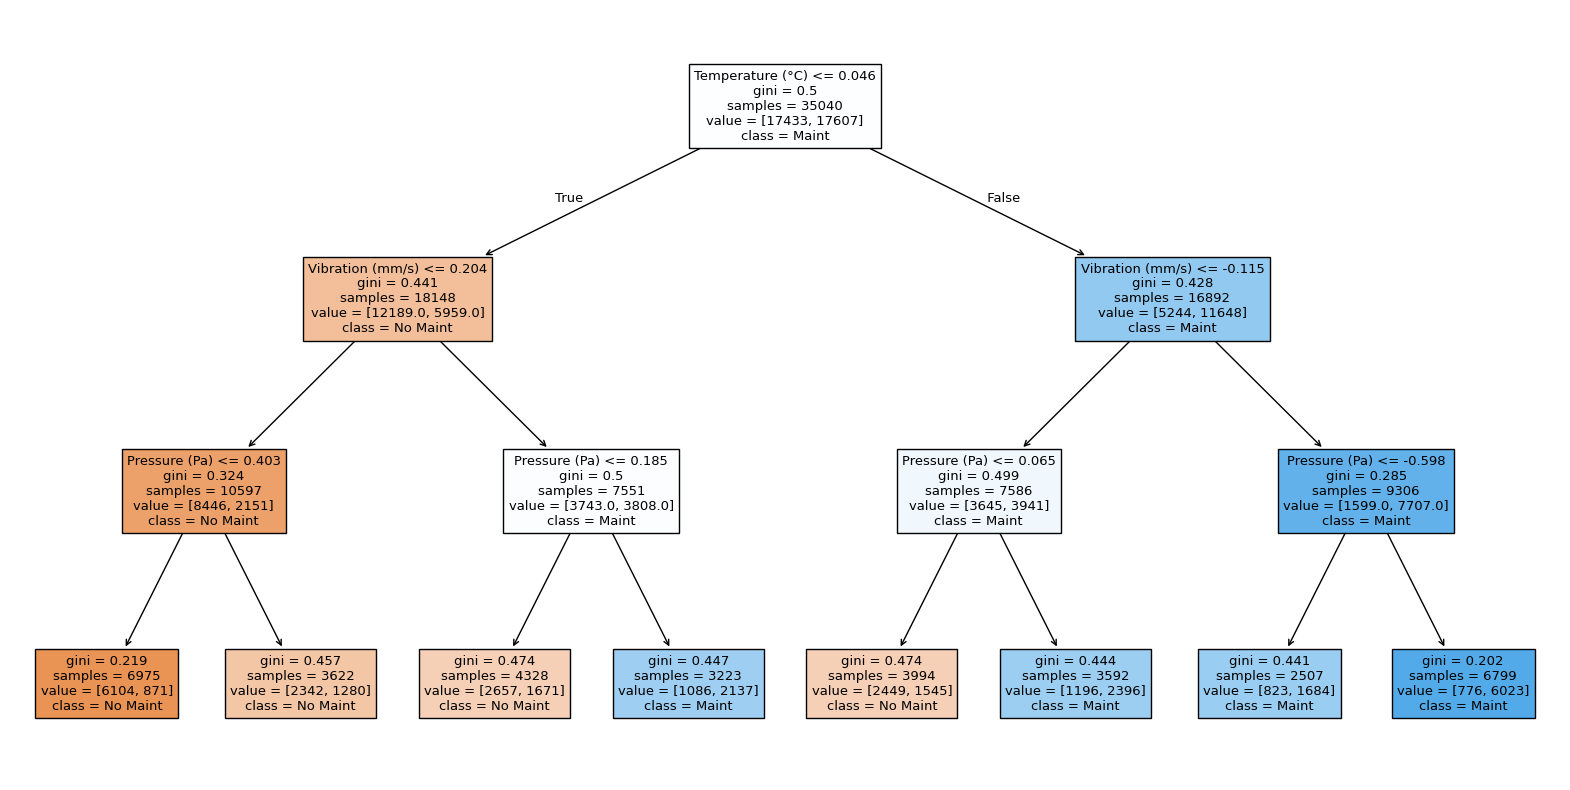


Tree Rules:

|--- Temperature (°C) <= 0.05
|   |--- Vibration (mm/s) <= 0.20
|   |   |--- Pressure (Pa) <= 0.40
|   |   |   |--- class: 0
|   |   |--- Pressure (Pa) >  0.40
|   |   |   |--- class: 0
|   |--- Vibration (mm/s) >  0.20
|   |   |--- Pressure (Pa) <= 0.18
|   |   |   |--- class: 0
|   |   |--- Pressure (Pa) >  0.18
|   |   |   |--- class: 1
|--- Temperature (°C) >  0.05
|   |--- Vibration (mm/s) <= -0.12
|   |   |--- Pressure (Pa) <= 0.07
|   |   |   |--- class: 0
|   |   |--- Pressure (Pa) >  0.07
|   |   |   |--- class: 1
|   |--- Vibration (mm/s) >  -0.12
|   |   |--- Pressure (Pa) <= -0.60
|   |   |   |--- class: 1
|   |   |--- Pressure (Pa) >  -0.60
|   |   |   |--- class: 1


Random Forest
Accuracy: 0.8192922374429223
Precision: 0.8148661126500462
Recall: 0.8188355369983763
F1 Score: 0.8168460025454125

Random Forest Importance:
             Feature  Importance
0  Temperature (°C)    0.293400
1  Vibration (mm/s)    0.234825
2     Pressure (Pa)    0.183622
3          

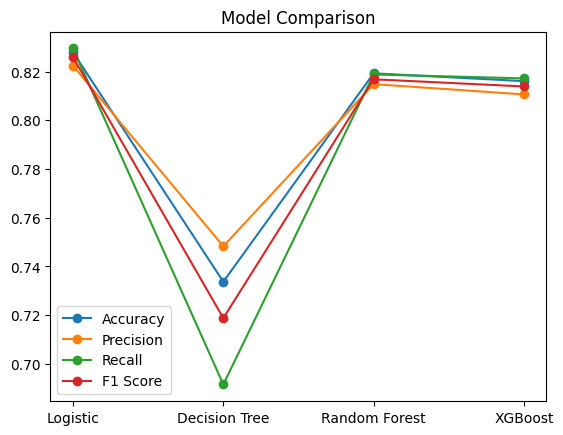

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load dataset
df = pd.read_csv("/content/synthetic_dataset.csv")

# Handle missing values
df = df.fillna(df.mean(numeric_only=True))

# Handle date column
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df = df.drop(columns=['date'])

# Keep numeric only
df = df.select_dtypes(include=[np.number])

# -----------------------------
# DEFINE FEATURES AND TARGET
# -----------------------------
# IMPORTANT: change this if your target name is different
target_column = "Maintenance Required"

X = df.drop(columns=[target_column])
y = df[target_column]

# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# SCALING (only for Logistic)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# LOGISTIC REGRESSION
# ============================================================
print("\nLogistic Regression")

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test, y_pred_log)
log_prec = precision_score(y_test, y_pred_log)
log_rec = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Accuracy:", log_acc)
print("Precision:", log_prec)
print("Recall:", log_rec)
print("F1 Score:", log_f1)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

# Feature importance (coefficients)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("\nLogistic Regression Feature Impact:\n", coefficients)

# ============================================================
# DECISION TREE
# ============================================================
print("\nDecision Tree")

dt_model = DecisionTreeClassifier(max_depth=3)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Accuracy:", dt_acc)
print("Precision:", dt_prec)
print("Recall:", dt_rec)
print("F1 Score:", dt_f1)

# Tree plot
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns,
          class_names=["No Maint", "Maint"], filled=True)
plt.show()

# Rules
print("\nTree Rules:\n")
print(export_text(dt_model, feature_names=list(X.columns)))

# ============================================================
# RANDOM FOREST
# ============================================================
print("\nRandom Forest")

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy:", rf_acc)
print("Precision:", rf_prec)
print("Recall:", rf_rec)
print("F1 Score:", rf_f1)

# Feature importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nRandom Forest Importance:\n", rf_importance)

# ============================================================
# XGBOOST
# ============================================================
print("\nXGBoost")

xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("Accuracy:", xgb_acc)
print("Precision:", xgb_prec)
print("Recall:", xgb_rec)
print("F1 Score:", xgb_f1)

# ============================================================
# FINAL COMPARISON
# ============================================================
results = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [log_acc, dt_acc, rf_acc, xgb_acc],
    "Precision": [log_prec, dt_prec, rf_prec, xgb_prec],
    "Recall": [log_rec, dt_rec, rf_rec, xgb_rec],
    "F1 Score": [log_f1, dt_f1, rf_f1, xgb_f1]
})

print("\nFINAL RESULTS:\n", results)

# Plot
x = np.arange(len(results))

plt.figure()
plt.plot(x, results["Accuracy"], marker='o', label="Accuracy")
plt.plot(x, results["Precision"], marker='o', label="Precision")
plt.plot(x, results["Recall"], marker='o', label="Recall")
plt.plot(x, results["F1 Score"], marker='o', label="F1 Score")

plt.xticks(x, results["Model"])
plt.legend()
plt.title("Model Comparison")
plt.show()

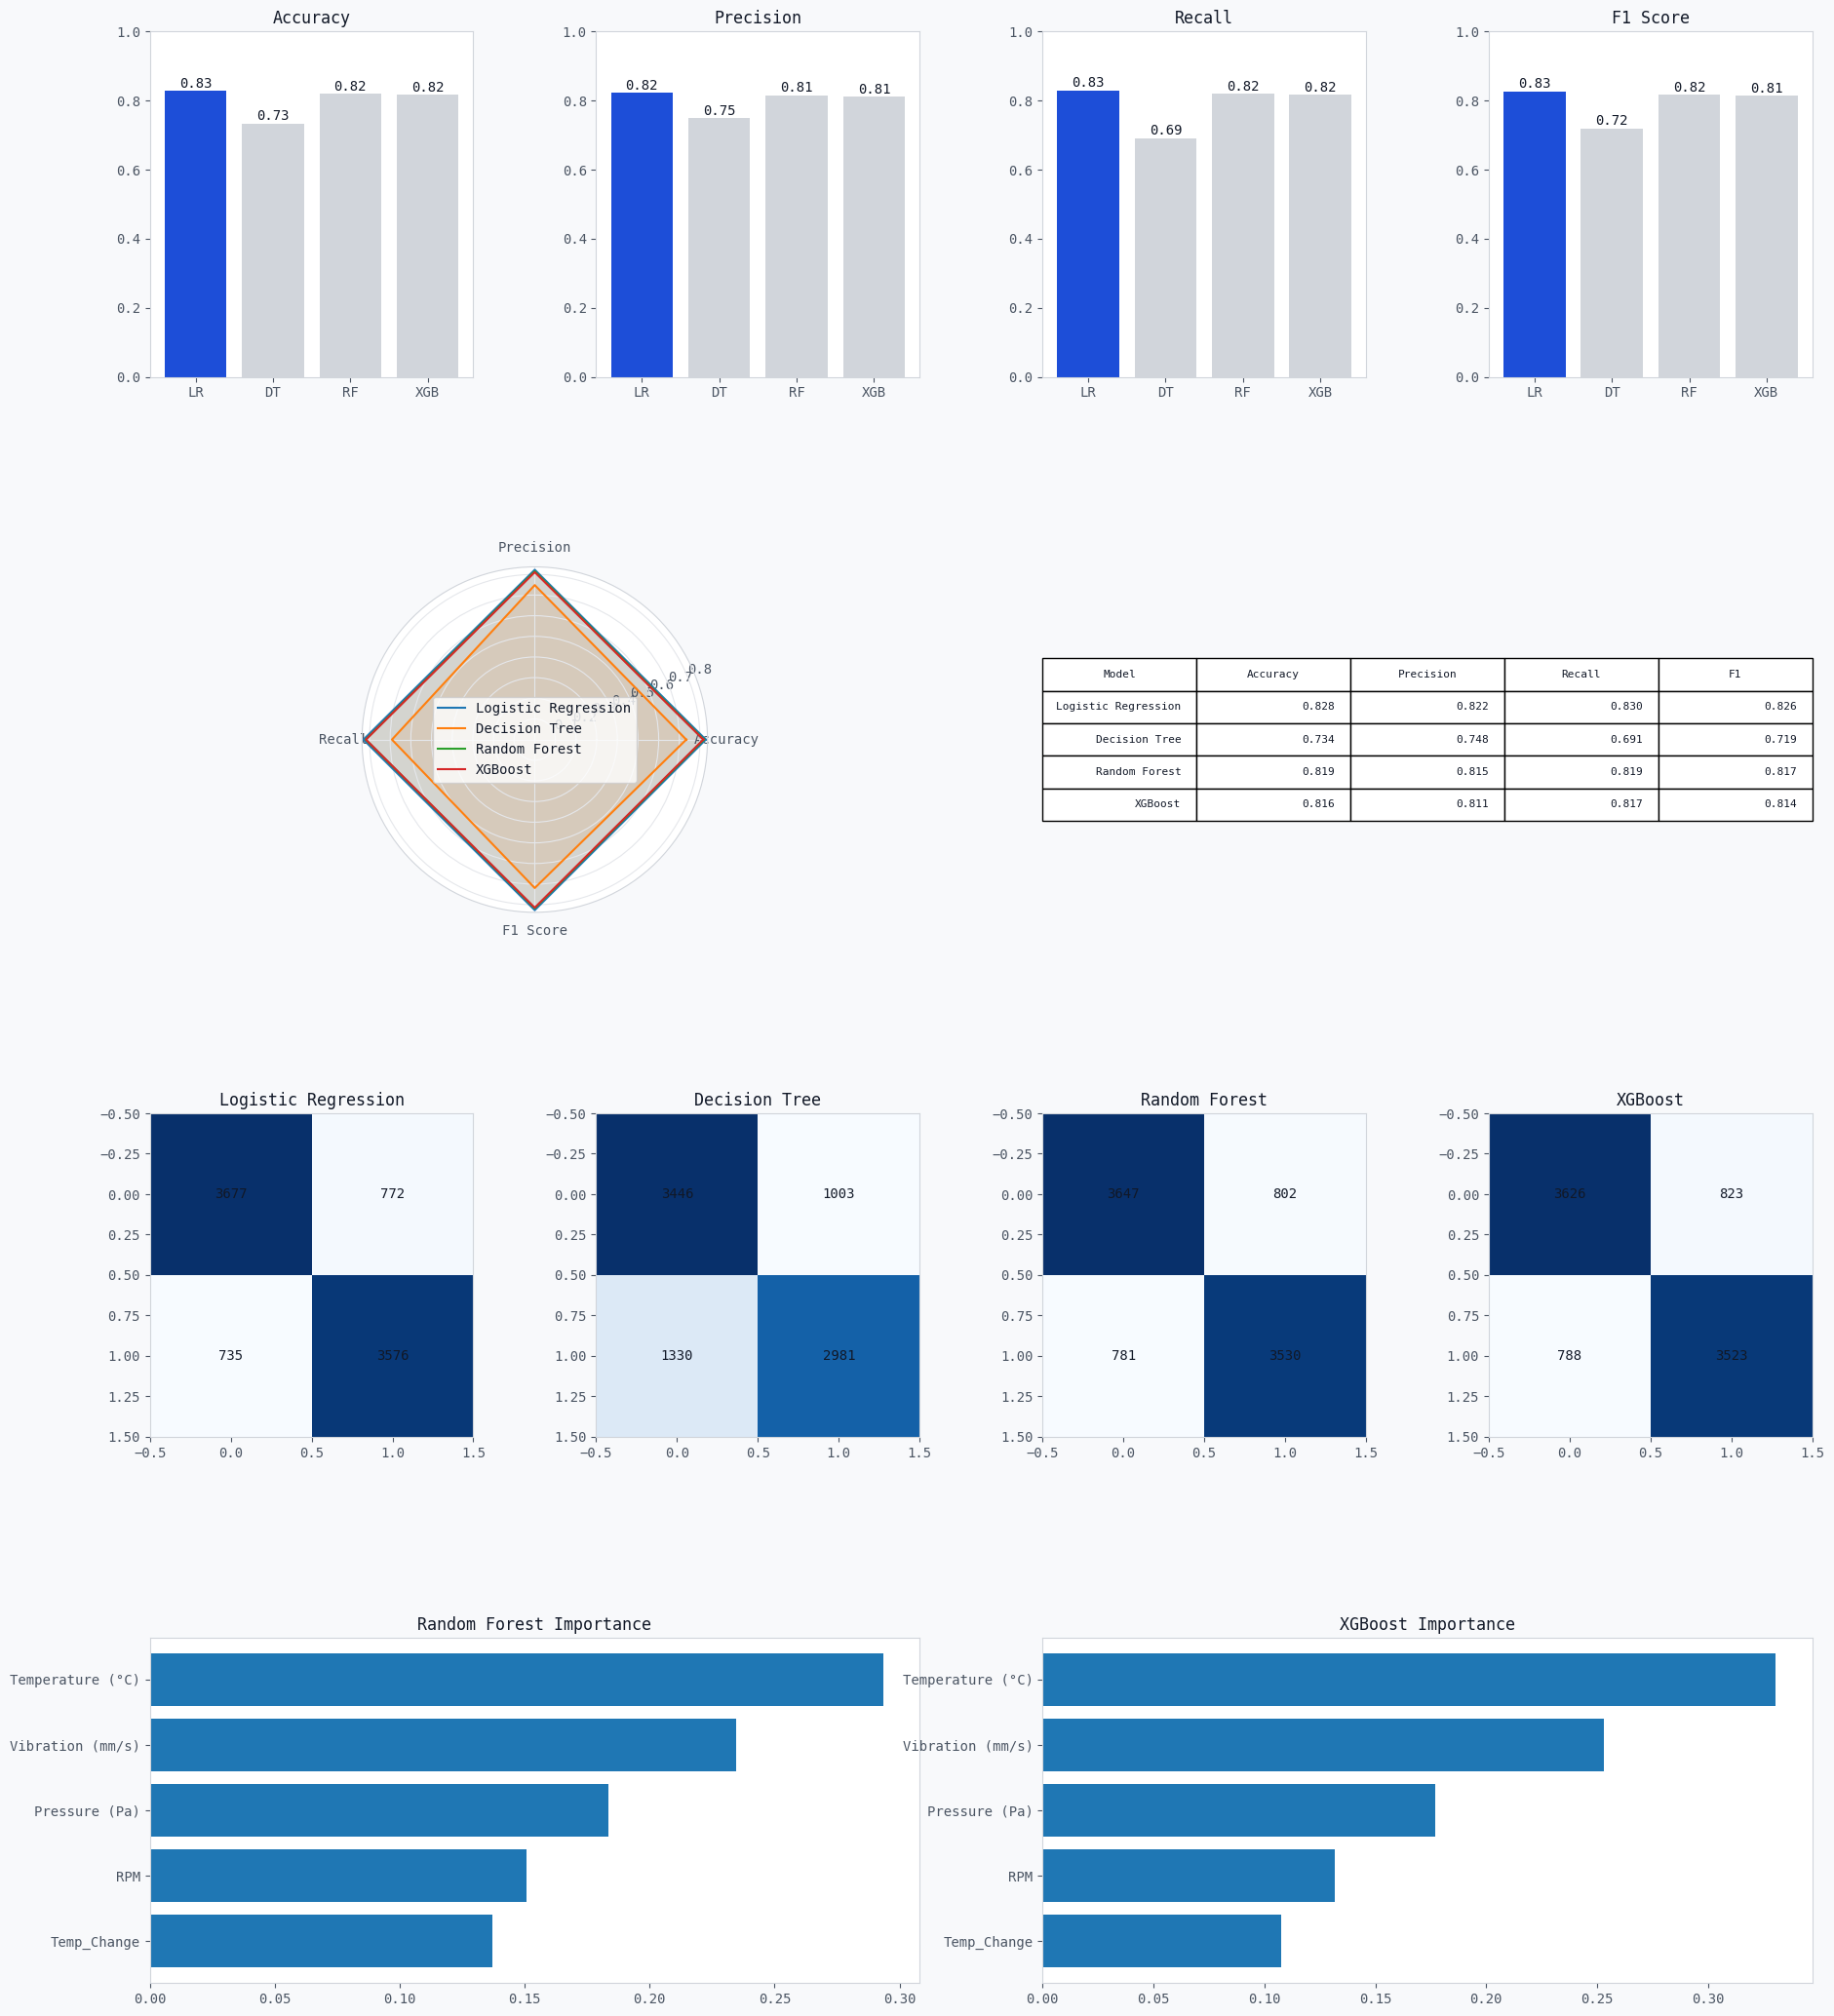

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

# ============================
# USE REAL MODEL RESULTS
# ============================

models = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"]
models_short = ["LR", "DT", "RF", "XGB"]

metrics = {
    "Accuracy":  [log_acc, dt_acc, rf_acc, xgb_acc],
    "Precision": [log_prec, dt_prec, rf_prec, xgb_prec],
    "Recall":    [log_rec, dt_rec, rf_rec, xgb_rec],
    "F1 Score":  [log_f1, dt_f1, rf_f1, xgb_f1],
}

# Confusion matrices (real)
conf_matrices = {
    "Logistic Regression": confusion_matrix(y_test, y_pred_log),
    "Decision Tree":       confusion_matrix(y_test, y_pred_dt),
    "Random Forest":       confusion_matrix(y_test, y_pred_rf),
    "XGBoost":             confusion_matrix(y_test, y_pred_xgb),
}

# Feature importance (real)
rf_features = list(X.columns)
rf_importance = rf_model.feature_importances_

xgb_features = list(X.columns)
xgb_importance = xgb_model.feature_importances_

# ============================
# STYLING
# ============================

BG, CARD, BORDER = "#f8f9fb", "#ffffff", "#d1d5db"
TEXT, SUBTEXT, GRID = "#111827", "#4b5563", "#e5e7eb"

ACCENT = ["#1d4ed8", "#7c3aed", "#059669", "#b45309"]
BAR_DIM = "#d1d5db"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": CARD,
    "axes.edgecolor": BORDER,
    "axes.labelcolor": TEXT,
    "xtick.color": SUBTEXT,
    "ytick.color": SUBTEXT,
    "text.color": TEXT,
    "grid.color": GRID,
    "font.family": "monospace",
})

fig = plt.figure(figsize=(22, 26))
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.38)

# ============================
# 1. METRIC CARDS
# ============================

metric_names = list(metrics.keys())

for col, mname in enumerate(metric_names):
    ax = fig.add_subplot(gs[0, col])
    vals = metrics[mname]

    best_idx = np.argmax(vals)
    colors = [ACCENT[i] if i == best_idx else BAR_DIM for i in range(4)]

    bars = ax.bar(models_short, vals, color=colors)

    ax.set_title(mname)
    ax.set_ylim(0, 1)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.2f}",
                ha='center')

# ============================
# 2. RADAR CHART
# ============================

ax_radar = fig.add_subplot(gs[1, 0:2], polar=True)

metric_keys = list(metrics.keys())
angles = np.linspace(0, 2*np.pi, len(metric_keys), endpoint=False).tolist()
angles += angles[:1]

for i in range(4):
    vals = [metrics[m][i] for m in metric_keys]
    vals += vals[:1]

    ax_radar.plot(angles, vals, label=models[i])
    ax_radar.fill(angles, vals, alpha=0.1)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metric_keys)
ax_radar.legend()

# ============================
# 3. SUMMARY TABLE
# ============================

ax_tbl = fig.add_subplot(gs[1, 2:4])
ax_tbl.axis("off")

rows = []
for i, m in enumerate(models):
    rows.append([
        m,
        f"{metrics['Accuracy'][i]:.3f}",
        f"{metrics['Precision'][i]:.3f}",
        f"{metrics['Recall'][i]:.3f}",
        f"{metrics['F1 Score'][i]:.3f}",
    ])

table = ax_tbl.table(
    cellText=rows,
    colLabels=["Model", "Accuracy", "Precision", "Recall", "F1"],
    loc="center"
)
table.scale(1, 2)

# ============================
# 4. CONFUSION MATRICES
# ============================

for i, (name, cm) in enumerate(conf_matrices.items()):
    ax = fig.add_subplot(gs[2, i])

    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)

    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            ax.text(c, r, cm[r, c], ha="center", va="center")

# ============================
# 5. FEATURE IMPORTANCE
# ============================

ax1 = fig.add_subplot(gs[3, 0:2])
ax2 = fig.add_subplot(gs[3, 2:4])

# Random Forest
order = np.argsort(rf_importance)
ax1.barh(np.array(rf_features)[order], rf_importance[order])
ax1.set_title("Random Forest Importance")

# XGBoost
order = np.argsort(xgb_importance)
ax2.barh(np.array(xgb_features)[order], xgb_importance[order])
ax2.set_title("XGBoost Importance")

plt.show()